Verified Train-only P80 threshold: 867.3624


/var/folders/zk/qp88mqcn6w36d5t2rzmnd23r0000gn/T/ipykernel_79490/3496169901.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=hvo_by_cat, x="Product_Category", y="hvo_rate_pct", palette="Blues_r")
/var/folders/zk/qp88mqcn6w36d5t2rzmnd23r0000gn/T/ipykernel_79490/3496169901.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_plot_df, x="is_high_value", y="Customer_Age", palette="Set2", showfliers=False)


All plots saved successfully.


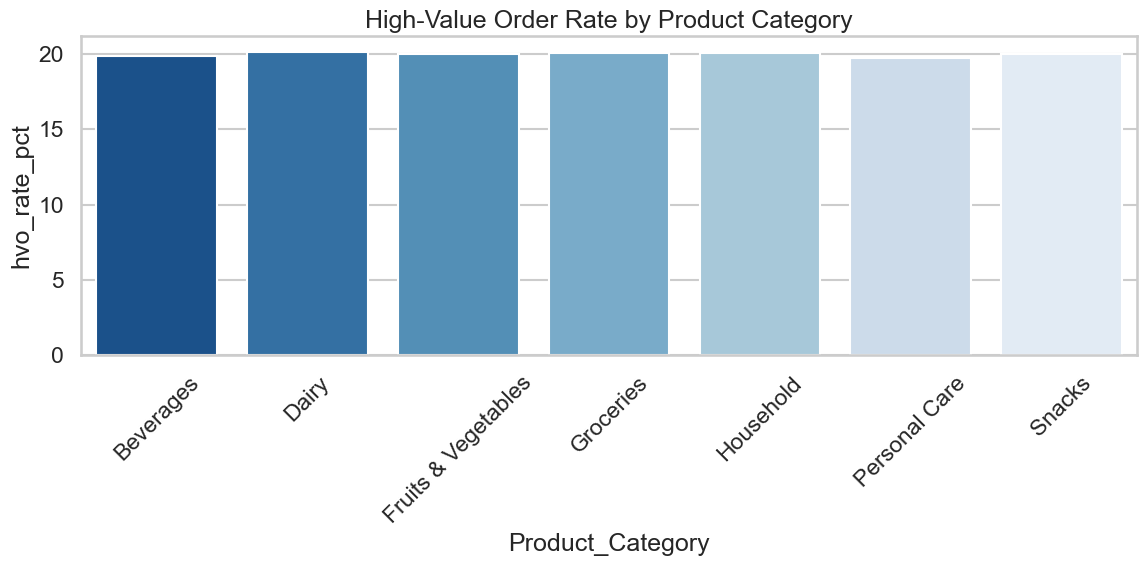

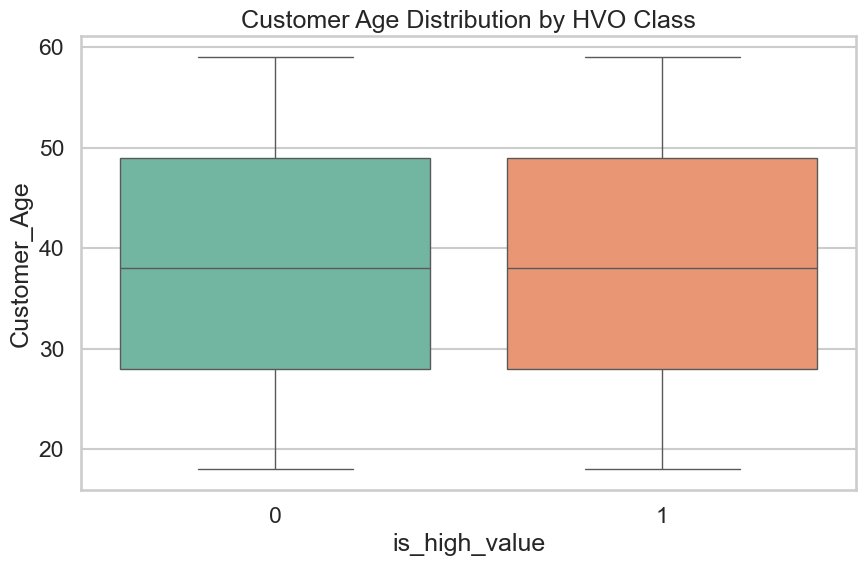

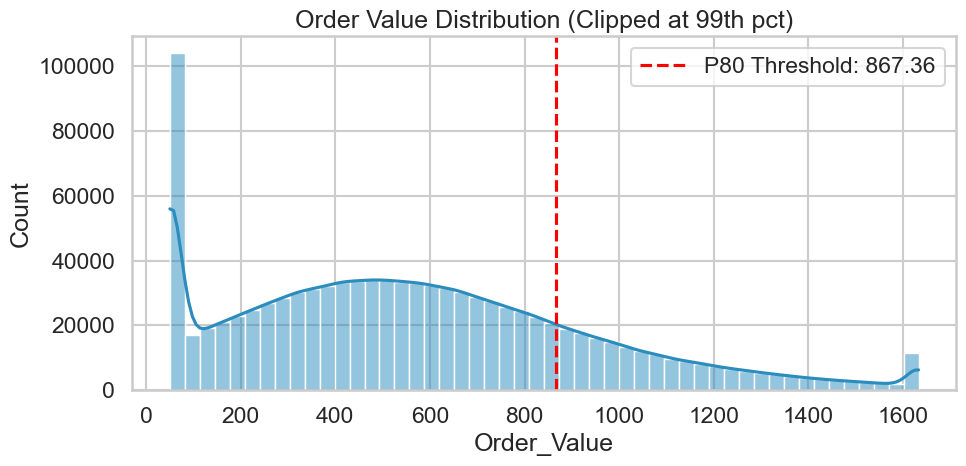

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Config 
# -----------------------------
CSV_PATH = "../data/quick_commerce_data_raw.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
COLS = ["Product_Category", "Customer_Age", "Order_Value", "City"]

# 強制使用低內存數據類型
DTYPE_MAP = {
    "Product_Category": "category",
    "Customer_Age": "float32",
    "Order_Value": "float32",
    "City": "category"
}

# -----------------------------
# 2. 數據加載與清洗
# -----------------------------
# 僅讀取需要的欄位以節省 RAM
df = pd.read_csv(CSV_PATH, usecols=COLS, dtype=DTYPE_MAP)

# 刪除 Order_Value 為空的行（因為無法定義目標變數）
df = df.dropna(subset=["Order_Value"]).copy()

# -----------------------------
# 3. 嚴謹的 ML 流程：先切分，再計算門檻 (防止 Leakage)
# -----------------------------
train_df, test_df = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# 僅在訓練集計算 P80 門檻
p80_train = float(train_df["Order_Value"].quantile(0.80))
print(f"Verified Train-only P80 threshold: {p80_train:.4f}")

# 建立標籤
train_df["is_high_value"] = (train_df["Order_Value"] >= p80_train).astype("int8")
test_df["is_high_value"] = (test_df["Order_Value"] >= p80_train).astype("int8")

# 為了繪圖方便，建立一個包含標籤的全域數據備份
eda_df = df.copy()
eda_df["is_high_value"] = (eda_df["Order_Value"] >= p80_train).astype("int8")

# -----------------------------
# 4. 視覺化 EDA (Visualisation)
# -----------------------------
sns.set_theme(style="whitegrid", context="talk")

# 圖 1: 各產品類別的高價值訂單率
cat_plot_df = eda_df.dropna(subset=["Product_Category"]).copy()
hvo_by_cat = (
    cat_plot_df.groupby("Product_Category", observed=True)["is_high_value"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
hvo_by_cat["hvo_rate_pct"] = hvo_by_cat["is_high_value"] * 100

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=hvo_by_cat, x="Product_Category", y="hvo_rate_pct", palette="Blues_r")
ax.set_title("High-Value Order Rate by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("hvo_by_category.png")

# 圖 2: 客戶年齡與高價值訂單的關係
age_plot_df = eda_df.dropna(subset=["Customer_Age"]).copy()
plt.figure(figsize=(9, 6))
sns.boxplot(data=age_plot_df, x="is_high_value", y="Customer_Age", palette="Set2", showfliers=False)
plt.title("Customer Age Distribution by HVO Class")
plt.tight_layout()
plt.savefig("age_vs_hvo.png")

# 圖 3: 訂單金額分佈與離群值檢查
ov = eda_df["Order_Value"].dropna()
plt.figure(figsize=(10, 5))
sns.histplot(ov.clip(upper=ov.quantile(0.99)), bins=50, kde=True, color="#2b8cbe")
plt.axvline(p80_train, color="red", linestyle="--", label=f"P80 Threshold: {p80_train:.2f}")
plt.title("Order Value Distribution (Clipped at 99th pct)")
plt.legend()
plt.tight_layout()
plt.savefig("order_value_dist.png")

print("All plots saved successfully.")

In [8]:
# data_quality_audit.py
# Usage:
#   python data_quality_audit.py --csv q_commerce_orders.csv
# Optional:
#   --target is_high_value --order-col Order_Value --chunksize 200000

import argparse
import numpy as np
import pandas as pd

def audit_missingness(csv_path: str, chunksize: int = 200_000):
    # Read columns first (no data load)
    cols = pd.read_csv(csv_path, nrows=0).columns.tolist()

    missing_counts = pd.Series(0, index=cols, dtype="int64")
    total_rows = 0

    for chunk in pd.read_csv(csv_path, chunksize=chunksize, low_memory=False):
        total_rows += len(chunk)
        missing_counts = missing_counts.add(chunk.isna().sum(), fill_value=0).astype("int64")

    missing_pct = (missing_counts / total_rows) * 100 if total_rows > 0 else 0
    missing_tbl = pd.DataFrame({
        "column": cols,
        "missing_count": missing_counts.values,
        "missing_pct": np.round(missing_pct.values, 2),
    }).sort_values(["missing_pct", "missing_count"], ascending=[False, False])

    return missing_tbl, total_rows


def ensure_target(df: pd.DataFrame, target_col: str, order_col: str):
    if target_col in df.columns:
        return df[target_col].astype("Int8"), None

    if order_col not in df.columns:
        raise ValueError(
            f"Target '{target_col}' not found and '{order_col}' missing, cannot create target."
        )

    p80 = df[order_col].quantile(0.80)
    target = (df[order_col] >= p80).astype("Int8")
    return target, float(p80)


def class_imbalance_report(csv_path: str, target_col: str, order_col: str):
    # Only load needed columns for target reporting
    cols = pd.read_csv(csv_path, nrows=0).columns.tolist()

    usecols = [target_col] if target_col in cols else [order_col]
    df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)

    target, p80_used = ensure_target(df, target_col, order_col)
    vc = target.value_counts(dropna=False).sort_index()

    total = int(vc.sum())
    out = pd.DataFrame({
        "class": vc.index.astype(str),
        "count": vc.values,
        "pct": np.round((vc.values / total) * 100, 2),
    })
    return out, total, p80_used


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--csv", required=True, help="Path to dataset CSV")
    parser.add_argument("--target", default="is_high_value", help="Target column name")
    parser.add_argument("--order-col", default="Order_Value", help="Order value column")
    parser.add_argument("--chunksize", type=int, default=200_000)
    args = parser.parse_args()

    # 1) Missingness audit (all columns, memory-efficient chunking)
    missing_tbl, n_rows = audit_missingness(args.csv, args.chunksize)

    print("\n=== DATA QUALITY AUDIT: MISSINGNESS ===")
    print(f"Total rows scanned: {n_rows:,}")
    print(missing_tbl.to_string(index=False))

    # Save evidence tables
    missing_tbl.to_csv("missing_value_report.csv", index=False)

    # 2) Class imbalance audit
    class_tbl, total_labeled, p80_used = class_imbalance_report(
        args.csv, args.target, args.order_col
    )

    print("\n=== CLASS IMBALANCE: is_high_value ===")
    if p80_used is not None:
        print(
            f"Note: '{args.target}' was not found. Built from '{args.order_col}' using P80={p80_used:.4f}."
        )
    print(f"Total labeled rows: {total_labeled:,}")
    print(class_tbl.to_string(index=False))

    class_tbl.to_csv("class_imbalance_report.csv", index=False)

    # 3) Modelling pitfall notes (short + report-ready)
    print("\n=== MODELLING PITFALL NOTES ===")
    print(
        "1) Accuracy can be misleading with class imbalance. "
        "If ~80% are non-HVO, a trivial model predicting all 0 can score ~80% accuracy "
        "while failing to identify high-value orders."
    )
    print(
        "2) Prefer PR-AUC, Recall, Precision, F1, and Precision@K/Recall@K for operational targeting."
    )
    print(
        "3) Exclude post-checkout/post-outcome fields (e.g., Delivery_Time_Min, Customer_Rating). "
        "These are unavailable at prediction time and leak future information, inflating offline metrics."
    )

CSV_PATH = "../data/quick_commerce_data_raw.csv"

missing_tbl, n_rows = audit_missingness(CSV_PATH)
print(missing_tbl.head())

class_tbl, total_labeled, p80_used = class_imbalance_report(
    CSV_PATH, "is_high_value", "Order_Value"
)
print(class_tbl)


                     column  missing_count  missing_pct
12  Delivery_Partner_Rating         104137        10.41
2                      City          52000         5.20
10          Customer_Rating          47000         4.70
7               Items_Count          35000         3.50
0                  Order_ID              0         0.00
  class   count   pct
0     0  800000  80.0
1     1  200000  20.0


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target_col = "is_high_value"
feature_cols = ["Customer_Age", "City", "Product_Category"]

# --- safety checks (加分：data validation) ---
missing_cols = [c for c in feature_cols + [target_col] if c not in train_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in train_df: {missing_cols}")

missing_cols_test = [c for c in feature_cols + [target_col] if c not in test_df.columns]
if missing_cols_test:
    raise ValueError(f"Missing columns in test_df: {missing_cols_test}")

# Keep only required columns + target
train_small = train_df[feature_cols + [target_col]].copy()
test_small  = test_df[feature_cols + [target_col]].copy()

X_train = train_small[feature_cols]
y_train = train_small[target_col].astype("int8")

X_test  = test_small[feature_cols]
y_test  = test_small[target_col].astype("int8")

numeric_features = ["Customer_Age"]
categorical_features = ["City", "Product_Category"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

# Fit on TRAIN only, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Preprocessing complete.")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")


Preprocessing complete.
X_train_processed shape: (800000, 21)
X_test_processed shape:  (200000, 21)
Train positive rate: 0.200, Test positive rate: 0.200


In [12]:
import re
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target_col = "is_high_value"
feature_cols = ["Customer_Age", "City", "Product_Category"]  # strict allow-list

# --- basic validation checks (加分) ---
for name, df_ in [("train_df", train_df), ("test_df", test_df)]:
    missing = [c for c in feature_cols + [target_col] if c not in df_.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

train_small = train_df[feature_cols + [target_col]].copy()
test_small  = test_df[feature_cols + [target_col]].copy()

X_train = train_small[feature_cols]
y_train = train_small[target_col].astype("int8")
X_test  = test_small[feature_cols]
y_test  = test_small[target_col].astype("int8")

numeric_features = ["Customer_Age"]
categorical_features = ["City", "Product_Category"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

# Fit on train only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Preprocessing complete.")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape:  {X_test_processed.shape}")
print(f"Train positive rate: {y_train.mean():.3f}, Test positive rate: {y_test.mean():.3f}")

# --- Feature transparency audit ---
feature_names = preprocessor.get_feature_names_out()
print("\n=== FEATURE TRANSPARENCY AUDIT ===")
print(f"Total engineered features: {len(feature_names)}")
print("First 15 feature names:")
for f in feature_names[:15]:
    print(" -", f)

# --- Leakage sanity check (keyword-based, simple but useful) ---
forbidden_keywords = ["order_value", "delivery", "time", "rating"]
pattern = re.compile("|".join(re.escape(k) for k in forbidden_keywords), flags=re.IGNORECASE)

raw_flagged = [c for c in X_train.columns if pattern.search(c)]
eng_flagged = [f for f in feature_names if pattern.search(f)]

print("\n=== LEAKAGE SANITY CHECK ===")
if raw_flagged or eng_flagged:
    print("WARNING: Potential leakage-related features detected.")
    if raw_flagged:
        print("Flagged raw cols:", raw_flagged)
    if eng_flagged:
        print("Flagged engineered:", eng_flagged[:20], "..." if len(eng_flagged) > 20 else "")
else:
    print("PASS: No forbidden keywords found in raw or engineered feature names.")


Preprocessing complete.
X_train_processed shape: (800000, 21)
X_test_processed shape:  (200000, 21)
Train positive rate: 0.200, Test positive rate: 0.200

=== FEATURE TRANSPARENCY AUDIT ===
Total engineered features: 21
First 15 feature names:
 - num__Customer_Age
 - cat__City_Amritsar
 - cat__City_Bengluru
 - cat__City_Chennai
 - cat__City_Delhi
 - cat__City_Gurgaon
 - cat__City_Haridwar
 - cat__City_Hyderabad
 - cat__City_Jaipur
 - cat__City_Kolkata
 - cat__City_Mumbai
 - cat__City_Noida
 - cat__City_Pune
 - cat__City_Unknown
 - cat__Product_Category_Beverages

=== LEAKAGE SANITY CHECK ===
PASS: No forbidden keywords found in raw or engineered feature names.


In [13]:
# -------------------------------------------------------------------
# 6) Validation discipline for imbalanced target (20% HVO / 80% non-HVO)
# -------------------------------------------------------------------
# Why Stratified CV?
# Regular KFold can create folds with uneven class ratios, which makes model
# selection unstable on imbalanced data. StratifiedKFold preserves the HVO/non-HVO
# proportion in each fold, so PR-AUC/recall estimates are more reliable.
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Example usage in next step:
# for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_processed, y_train), 1):
#     X_tr, X_va = X_train_processed[tr_idx], X_train_processed[va_idx]
#     y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
#     ...


In [23]:
# Step 4: Model shortlisting (LogReg vs Tree Boosting)
# Assumes these already exist from Step 3:
# - X_train_processed, X_test_processed (sparse matrices from OneHotEncoder)
# - y_train, y_test (binary labels)
# - cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.ensemble import HistGradientBoostingClassifier

# -------------------------------------------------------------------
# Why a tree-based boosting model may outperform Logistic Regression:
# - Logistic Regression is linear in the (one-hot) feature space. It can miss
#   non-linear patterns and interactions (e.g., certain City × Category combos
#   behaving very differently for younger vs older customers).
# - Gradient boosting trees can learn non-linear decision rules and feature
#   interactions, which often helps on tabular commerce datasets.
#
# Note: XGBoost was originally considered, but due to environment constraints
# (library compatibility), we use scikit-learn's HistGradientBoostingClassifier
# as a modern tree-boosting benchmark.
# -------------------------------------------------------------------

# Ensure y are 1D numpy arrays
y_train_arr = np.asarray(y_train).ravel()
y_test_arr  = np.asarray(y_test).ravel()

# HistGradientBoostingClassifier does NOT accept sparse matrices.
# Our processed matrices have only 21 columns, so converting to dense is safe.
X_train_dense = X_train_processed.toarray()
X_test_dense  = X_test_processed.toarray()

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        random_state=42,
    ),
}

def get_X_for_model(model_name: str):
    """Return the appropriate design matrix format (sparse vs dense)."""
    if model_name == "HistGradientBoosting":
        return X_train_dense, X_test_dense
    return X_train_processed, X_test_processed  

def predict_proba_1(model, X):
    """Safely get positive-class scores. Prefer predict_proba, fallback to decision_function."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # Fallback: convert decision scores to [0,1] via logistic sigmoid
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))



=== 5-Fold Stratified CV (Train only) ===
               model       CV PR-AUC           CV F1 CV Balanced Acc
  LogisticRegression 0.2494 ± 0.0010 0.3245 ± 0.0015 0.5548 ± 0.0014
HistGradientBoosting 0.2488 ± 0.0004 0.0000 ± 0.0000 0.5000 ± 0.0000

=== Hold-out Test Performance ===
               model  Test PR-AUC  Test F1  Test Balanced Acc
  LogisticRegression       0.2509   0.3258             0.5563
HistGradientBoosting       0.2490   0.0000             0.5000


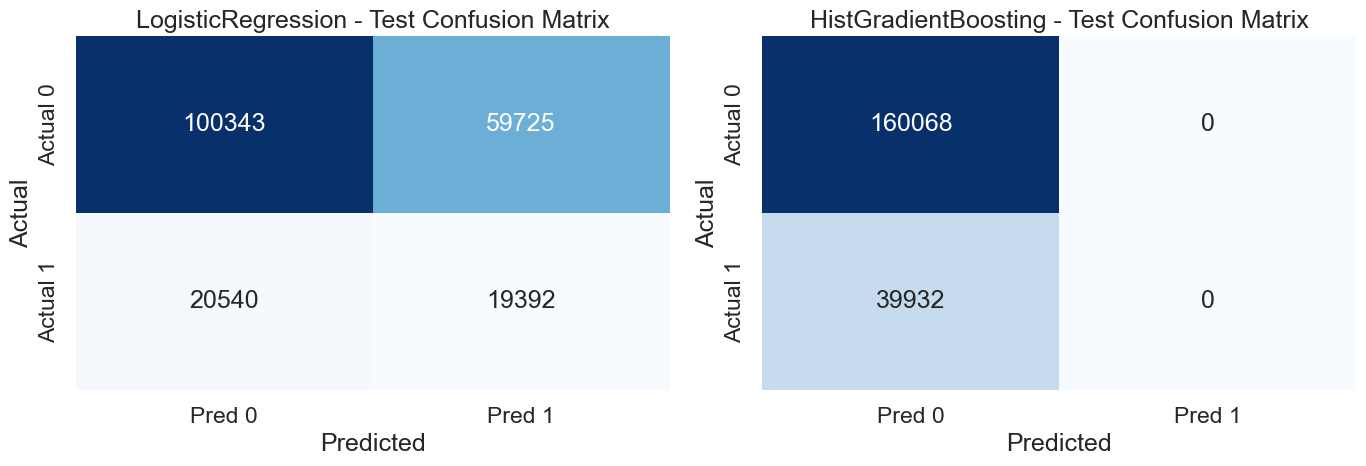

In [27]:
# -------------------------------------------------------------------
# Remaining Step 4: CV + hold-out test evaluation + confusion matrices
# Uses existing objects from your script:
# - models, get_X_for_model(), predict_proba_1()
# - X_train_processed, X_test_processed, X_train_dense, X_test_dense
# - y_train_arr, y_test_arr, cv
# -------------------------------------------------------------------

def cv_evaluate_model(model_name, model, cv_obj, threshold=0.5):
    """5-fold stratified CV on training set (no test usage)."""
    X_train_model, _ = get_X_for_model(model_name)

    pr_scores, f1_scores, bal_scores = [], [], []

    for tr_idx, va_idx in cv_obj.split(X_train_model, y_train_arr):
        # HistGB needs dense; LogReg works well with sparse.
        X_tr, X_va = X_train_model[tr_idx], X_train_model[va_idx]
        y_tr, y_va = y_train_arr[tr_idx], y_train_arr[va_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        y_va_prob = predict_proba_1(m, X_va)
        y_va_pred = (y_va_prob >= threshold).astype(int)

        pr_scores.append(average_precision_score(y_va, y_va_prob))  # PR-AUC (primary)
        f1_scores.append(f1_score(y_va, y_va_pred, zero_division=0))
        bal_scores.append(balanced_accuracy_score(y_va, y_va_pred))

    return {
        "cv_pr_auc_mean": np.mean(pr_scores),
        "cv_pr_auc_std": np.std(pr_scores),
        "cv_f1_mean": np.mean(f1_scores),
        "cv_f1_std": np.std(f1_scores),
        "cv_bal_acc_mean": np.mean(bal_scores),
        "cv_bal_acc_std": np.std(bal_scores),
    }


results = []
test_preds = {}

for model_name, model in models.items():
    # 1) CV on training set only (stratified to preserve 20/80 class ratio per fold)
    cv_metrics = cv_evaluate_model(model_name, model, cv, threshold=0.5)

    # 2) Fit on full training set, evaluate once on hold-out test set
    X_train_model, X_test_model = get_X_for_model(model_name)
    final_model = clone(model)
    final_model.fit(X_train_model, y_train_arr)

    y_test_prob = predict_proba_1(final_model, X_test_model)
    y_test_pred = (y_test_prob >= 0.5).astype(int)
    test_preds[model_name] = y_test_pred

    test_metrics = {
        "test_pr_auc": average_precision_score(y_test_arr, y_test_prob),
        "test_f1": f1_score(y_test_arr, y_test_pred, zero_division=0),
        "test_bal_acc": balanced_accuracy_score(y_test_arr, y_test_pred),
    }

    results.append({"model": model_name, **cv_metrics, **test_metrics})

summary_df = pd.DataFrame(results).sort_values("test_pr_auc", ascending=False)

# CV summary in mean ± std format
cv_summary = summary_df[[
    "model",
    "cv_pr_auc_mean", "cv_pr_auc_std",
    "cv_f1_mean", "cv_f1_std",
    "cv_bal_acc_mean", "cv_bal_acc_std",
]].copy()

cv_summary["CV PR-AUC"] = cv_summary.apply(
    lambda r: f"{r['cv_pr_auc_mean']:.4f} ± {r['cv_pr_auc_std']:.4f}", axis=1
)
cv_summary["CV F1"] = cv_summary.apply(
    lambda r: f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}", axis=1
)
cv_summary["CV Balanced Acc"] = cv_summary.apply(
    lambda r: f"{r['cv_bal_acc_mean']:.4f} ± {r['cv_bal_acc_std']:.4f}", axis=1
)

cv_summary = cv_summary[["model", "CV PR-AUC", "CV F1", "CV Balanced Acc"]]

test_summary = summary_df[["model", "test_pr_auc", "test_f1", "test_bal_acc"]].copy()
test_summary = test_summary.rename(columns={
    "test_pr_auc": "Test PR-AUC",
    "test_f1": "Test F1",
    "test_bal_acc": "Test Balanced Acc",
})

print("\n=== 5-Fold Stratified CV (Train only) ===")
print(cv_summary.to_string(index=False))

print("\n=== Hold-out Test Performance ===")
print(test_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 3) Confusion matrix heatmaps on hold-out test set (threshold=0.5)
fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test_arr, y_pred, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
    )
    ax.set_title(f"{model_name} - Test Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()



=== 5-Fold Stratified CV (Train only, threshold tuned for F1) ===
               model       CV PR-AUC   CV F1 (tuned) CV Bal Acc (tuned)  Chosen threshold (median CV)
  LogisticRegression 0.2494 ± 0.0010 0.3486 ± 0.0004    0.5413 ± 0.0006                          0.36
HistGradientBoosting 0.2489 ± 0.0003 0.3486 ± 0.0004    0.5412 ± 0.0006                          0.43

=== Hold-out Test (using CV-tuned threshold) ===
               model  Test PR-AUC  Test F1  Test Balanced Acc
  LogisticRegression       0.2509   0.3482             0.5414
HistGradientBoosting       0.2495   0.3482             0.5414


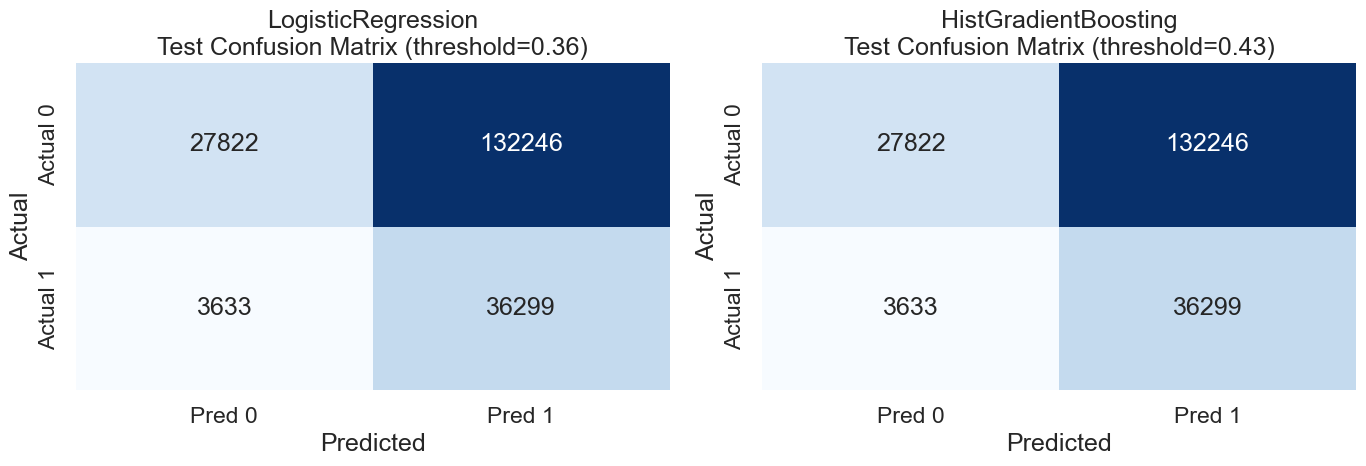

In [28]:
# Step 4 (improved): imbalance-aware boosting + CV threshold tuning
# Assumes already available from Step 3:
# - X_train_processed, X_test_processed (sparse)
# - X_train_dense, X_test_dense (dense copies for HistGB)
# - y_train_arr, y_test_arr (1D arrays)
# - cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# - get_X_for_model(model_name), predict_proba_1(model, X)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_sample_weight

# Why this matters:
# 1) Imbalance handling is critical for boosting: without it, loss minimization can prefer majority-class predictions.
# 2) PR-AUC can stay similar even when thresholded predictions collapse, because PR-AUC evaluates ranking quality
#    across ALL thresholds, while confusion matrix is tied to ONE chosen threshold (e.g., 0.5).

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        random_state=42,
        # No class_weight in many sklearn versions -> use sample_weight in fit()
    ),
}

def fit_model_with_imbalance(model_name, model, X, y):
    """Fit model with appropriate imbalance handling."""
    m = clone(model)
    if model_name == "HistGradientBoosting":
        # Dense required because HistGB does not accept sparse matrices.
        sw = compute_sample_weight(class_weight="balanced", y=y)
        m.fit(X, y, sample_weight=sw)
    else:
        m.fit(X, y)  # LogReg already uses class_weight="balanced"
    return m

def best_threshold_for_f1(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def cv_evaluate_with_tuning(model_name, model, cv_obj):
    X_train_model, _ = get_X_for_model(model_name)

    pr_list, f1_list, bal_list, thr_list = [], [], [], []

    for tr_idx, va_idx in cv_obj.split(X_train_model, y_train_arr):
        X_tr, X_va = X_train_model[tr_idx], X_train_model[va_idx]
        y_tr, y_va = y_train_arr[tr_idx], y_train_arr[va_idx]

        fitted = fit_model_with_imbalance(model_name, model, X_tr, y_tr)
        y_va_prob = predict_proba_1(fitted, X_va)

        # Primary ranking metric (threshold-independent)
        pr = average_precision_score(y_va, y_va_prob)

        # Tune threshold on validation fold for classification metrics
        t_star, _ = best_threshold_for_f1(y_va, y_va_prob)
        y_va_pred = (y_va_prob >= t_star).astype(int)

        f1 = f1_score(y_va, y_va_pred, zero_division=0)
        bal = balanced_accuracy_score(y_va, y_va_pred)

        pr_list.append(pr)
        f1_list.append(f1)
        bal_list.append(bal)
        thr_list.append(t_star)

    return {
        "cv_pr_auc_mean": np.mean(pr_list),
        "cv_pr_auc_std": np.std(pr_list),
        "cv_f1_mean": np.mean(f1_list),
        "cv_f1_std": np.std(f1_list),
        "cv_bal_acc_mean": np.mean(bal_list),
        "cv_bal_acc_std": np.std(bal_list),
        "cv_threshold_mean": np.mean(thr_list),
        "cv_threshold_median": np.median(thr_list),
    }

rows = []
test_preds = {}

for model_name, model in models.items():
    # 1) CV on training set only
    cv_metrics = cv_evaluate_with_tuning(model_name, model, cv)

    # Use CV-derived threshold (median is robust)
    tuned_threshold = float(cv_metrics["cv_threshold_median"])

    # 2) Fit on full training set (still no test leakage)
    X_train_model, X_test_model = get_X_for_model(model_name)
    final_model = fit_model_with_imbalance(model_name, model, X_train_model, y_train_arr)

    y_test_prob = predict_proba_1(final_model, X_test_model)
    y_test_pred = (y_test_prob >= tuned_threshold).astype(int)
    test_preds[model_name] = (y_test_pred, tuned_threshold)

    test_pr = average_precision_score(y_test_arr, y_test_prob)
    test_f1 = f1_score(y_test_arr, y_test_pred, zero_division=0)
    test_bal = balanced_accuracy_score(y_test_arr, y_test_pred)

    rows.append({
        "model": model_name,
        **cv_metrics,
        "test_pr_auc": test_pr,
        "test_f1": test_f1,
        "test_bal_acc": test_bal,
    })

summary = pd.DataFrame(rows).sort_values("test_pr_auc", ascending=False)

# Pretty CV summary (mean ± std)
cv_table = summary[[
    "model",
    "cv_pr_auc_mean", "cv_pr_auc_std",
    "cv_f1_mean", "cv_f1_std",
    "cv_bal_acc_mean", "cv_bal_acc_std",
    "cv_threshold_median",
]].copy()

cv_table["CV PR-AUC"] = cv_table.apply(
    lambda r: f"{r['cv_pr_auc_mean']:.4f} ± {r['cv_pr_auc_std']:.4f}", axis=1
)
cv_table["CV F1 (tuned)"] = cv_table.apply(
    lambda r: f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}", axis=1
)
cv_table["CV Bal Acc (tuned)"] = cv_table.apply(
    lambda r: f"{r['cv_bal_acc_mean']:.4f} ± {r['cv_bal_acc_std']:.4f}", axis=1
)

cv_table = cv_table[["model", "CV PR-AUC", "CV F1 (tuned)", "CV Bal Acc (tuned)", "cv_threshold_median"]]
cv_table = cv_table.rename(columns={"cv_threshold_median": "Chosen threshold (median CV)"})

test_table = summary[["model", "test_pr_auc", "test_f1", "test_bal_acc"]].copy()
test_table = test_table.rename(columns={
    "test_pr_auc": "Test PR-AUC",
    "test_f1": "Test F1",
    "test_bal_acc": "Test Balanced Acc",
})

print("\n=== 5-Fold Stratified CV (Train only, threshold tuned for F1) ===")
print(cv_table.to_string(index=False))

print("\n=== Hold-out Test (using CV-tuned threshold) ===")
print(test_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Confusion matrices with tuned threshold
fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models.keys()):
    y_pred, thr = test_preds[model_name]
    cm = confusion_matrix(y_test_arr, y_pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
    )
    ax.set_title(f"{model_name}\nTest Confusion Matrix (threshold={thr:.2f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()
